# 🇬🇧 → 🇫🇷 English to French Neural Machine Translation
## Using NLTK AND seq2seq with tensorflow,dataset- Tatoeba (Eng-fra) dataset

### Step 1: Environment Setup and Library Installation

Install and import all the required libraries needed for the Neural Machine Translation (NMT) project.

**Key tasks performed:**

* Install required libraries such as TensorFlow, NLTK, Matplotlib, Seaborn, and Scikit-learn.
* Import essential Python modules for data processing, visualization, and model training.
* Download NLTK resources (`punkt` and `stopwords`) used for text preprocessing.
* Check TensorFlow version and verify GPU availability to ensure faster model training.
* Set random seeds to ensure reproducibility of results.


In [ ]:
!pip install -q nltk tensorflow matplotlib seaborn scikit-learn

import os, re, time, random, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from collections import Counter
import unicodedata

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU Available: {tf.config.list_physical_devices('GPU')}")

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

TensorFlow version: 2.19.0
GPU Available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Step 2: Experiment Configuration

In [ ]:
CONFIG = {
    # Data
    "data_path": "fra.txt",              ##path to the tatoeba dataset file
    "num_samples": 80000,                ##number of sentence pairs to use 
    "max_eng_len": 20,                   ##maximum length of English sentences
    "max_fra_len": 25,                   ##maximum length of French sentences
    "min_freq": 2,                       ##minimum frequency of words to be included in vocabulary

    # Model — increased regularization
    "embedding_dim": 256,                ##size of word embeddings.
    "units": 512,                        ##units in the LSTM layers
    "dropout": 0.4,                      ##regularization to reduce overfitting.
    "recurrent_dropout": 0.2,    

    # Training
    "batch_size": 256,                   ##number of samples processed in each training step.
    "epochs": 30,                        ##number of training iterations.                                                   
    "learning_rate": 0.001,              ##step size for the optimizer.
    "patience": 7,                       ##number of epochs before early stopping.
    "val_split": 0.1,                    ##data sliptting ratio
    "test_split": 0.1,

    # Special tokens
    "START_TOKEN": "<start>",            ##<start> – marks the beginning of a sentence.
    "END_TOKEN": "<end>",                ##<end> – marks the end of a sentence.
    "OOV_TOKEN": "<oov>",                ##<oov> – used for unknown words not in the vocabulary.
    "PAD_TOKEN": "<pad>",                ##<pad> – used to pad sequences to equal length.
}

STEP 3:Data Preprocessing and loading 

In [ ]:
def unicode_to_ascii(s):                                                    ##unicode to ascii format conversion function
    """Convert unicode to ASCII (handles French accents properly)."""
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
    )

def preprocess_english(sentence):                                           ##preprocessing function for english sentences
    """Clean and normalize English sentence."""
    sentence = sentence.lower().strip()                                     ##Convert sentences to lowercase.
    sentence = re.sub(r"([?.!,¿])", r" \1 ", sentence)                      ##Remove unwanted characters.
    sentence = re.sub(r'[" "]+', " ", sentence)                             ##Replace multiple spaces with a single space.
    sentence = re.sub(r"[^a-zA-Z?.!,\']+", " ", sentence)                   ##Keep only letters and basic punctuation.
    sentence = sentence.strip()                                             ##Remove leading/trailing whitespace.
    return sentence

def preprocess_french(sentence):                                            ##preprocessing function for french sentences
    """Clean and normalize French sentence (keep accents)."""
    sentence = sentence.lower().strip()                                
    sentence = re.sub(r"([?.!,¿«»])", r" \1 ", sentence)         
    sentence = re.sub(r'[" "]+', " ", sentence)
    sentence = re.sub(r"[^a-zA-ZàâäéèêëîïôùûüÿçœæÀÂÄÉÈÊËÎÏÔÙÛÜŸÇŒÆ?.!,\'-]+", " ", sentence)   
    sentence = sentence.strip()
    return sentence

def load_tatoeba(path, num_samples, max_eng_len, max_fra_len):              ##loading the tatoeba dataset
    """
    Load Tatoeba fra.txt file.
    Format: English TAB French TAB Attribution
    """
    eng_sentences, fra_sentences = [], []

    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.strip().split('\t')                               ##Split line into English and French parts.
            if len(parts) < 2:
                continue
            eng = preprocess_english(parts[0])
            fra = preprocess_french(parts[1])

            eng_tokens = eng.split()
            fra_tokens = fra.split()

            # Length filtering
            if (1 <= len(eng_tokens) <= max_eng_len and
                1 <= len(fra_tokens) <= max_fra_len):
                eng_sentences.append(eng)
                fra_sentences.append(
                    CONFIG["START_TOKEN"] + " " + fra + " " + CONFIG["END_TOKEN"]
                )

    # Shuffle and sample
    combined = list(zip(eng_sentences, fra_sentences))
    random.shuffle(combined)
    combined = combined[:num_samples]
    eng_sentences, fra_sentences = zip(*combined)

    return list(eng_sentences), list(fra_sentences)


print("Loading Tatoeba dataset...")                                           ##loading the tatoeba dataset and printing some sample pairs
eng_sentences, fra_sentences = load_tatoeba(
    CONFIG["data_path"],
    CONFIG["num_samples"],
    CONFIG["max_eng_len"],
    CONFIG["max_fra_len"]
)

print(f"Total sentence pairs loaded: {len(eng_sentences):,}")
print("\nSample pairs:")
for i in random.sample(range(len(eng_sentences)), 5):
    print(f"  EN: {eng_sentences[i]}")
    print(f"  FR: {fra_sentences[i]}\n")


Loading Tatoeba dataset...
Total sentence pairs loaded: 80,000

Sample pairs:
  EN: they enjoyed themselves .
  FR: <start> elles se sont amusées . <end>

  EN: a bad writer's prose is full of hackneyed phrases .
  FR: <start> la prose d'un mauvais écrivain est pleine de phrases éculées . <end>

  EN: haven't we met somewhere before ?
  FR: <start> on ne s'est pas déjà rencontrés quelque part ? <end>

  EN: stop acting like a spoiled kid .
  FR: <start> cesse d'agir comme un enfant gâté ! <end>

  EN: please come hungry .
  FR: <start> venez , s'il vous plaît , en ayant faim . <end>



STEP 4:Dataset Statistics


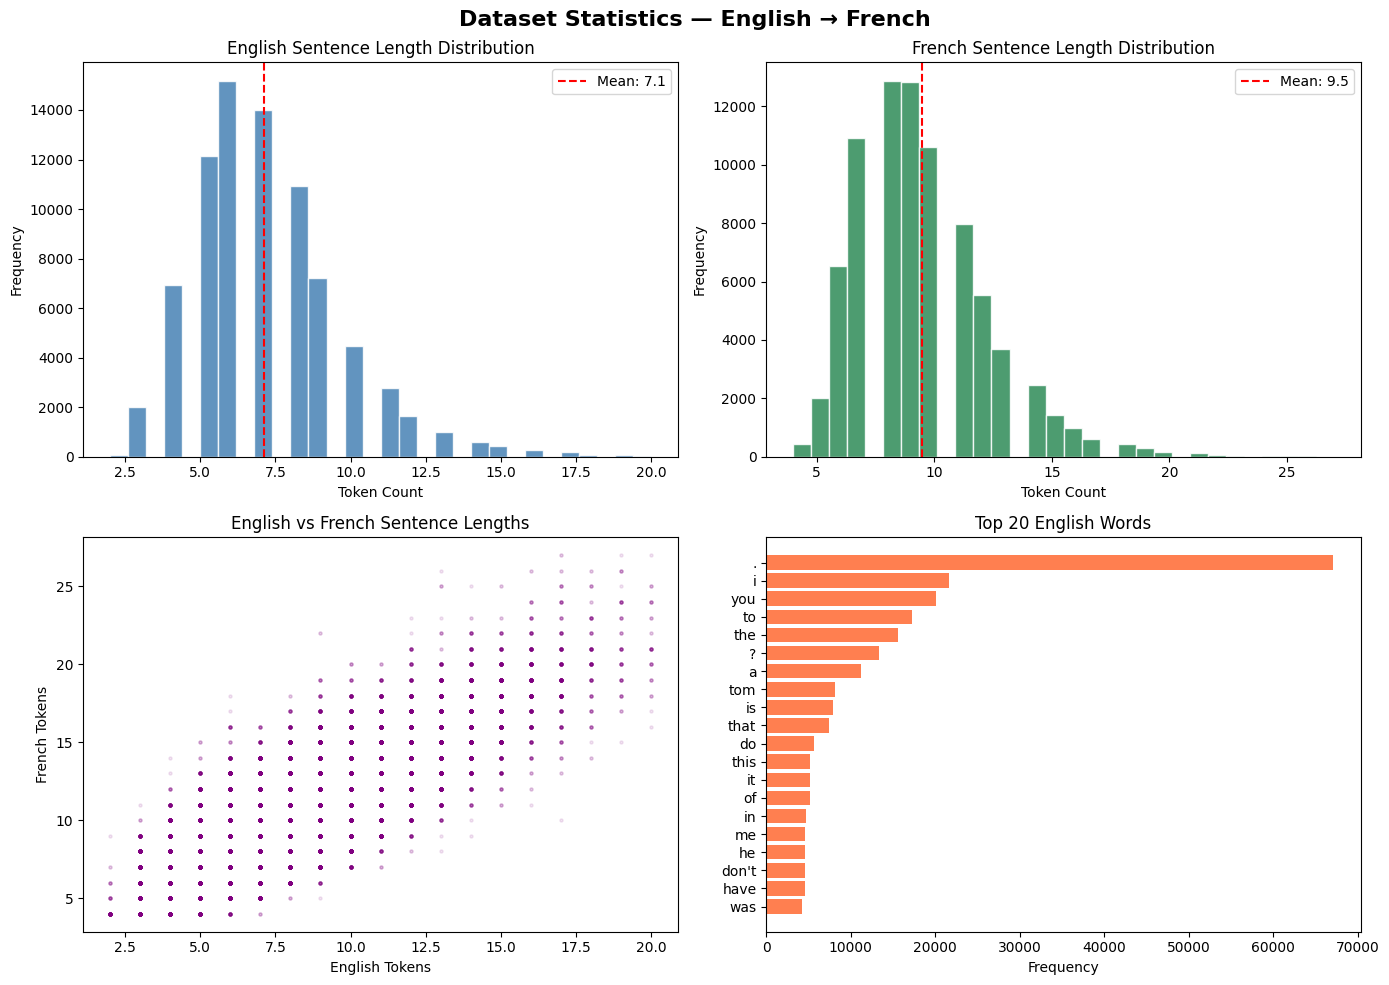

Saved: dataset_statistics.png


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))                           ##visualize dataset statistics with histograms and scatter plots                 
fig.suptitle("Dataset Statistics — English → French", fontsize=16, fontweight='bold')

eng_lens = [len(s.split()) for s in eng_sentences]
fra_lens = [len(s.split()) for s in fra_sentences]

# English length distribution
axes[0, 0].hist(eng_lens, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0, 0].set_title("English Sentence Length Distribution")
axes[0, 0].set_xlabel("Token Count")
axes[0, 0].set_ylabel("Frequency")
axes[0, 0].axvline(np.mean(eng_lens), color='red', linestyle='--', label=f'Mean: {np.mean(eng_lens):.1f}')
axes[0, 0].legend()

# French length distribution
axes[0, 1].hist(fra_lens, bins=30, color='seagreen', edgecolor='white', alpha=0.85)
axes[0, 1].set_title("French Sentence Length Distribution")
axes[0, 1].set_xlabel("Token Count")
axes[0, 1].set_ylabel("Frequency")
axes[0, 1].axvline(np.mean(fra_lens), color='red', linestyle='--', label=f'Mean: {np.mean(fra_lens):.1f}')
axes[0, 1].legend()

# Scatter: EN vs FR length
axes[1, 0].scatter(eng_lens, fra_lens, alpha=0.1, s=5, color='purple')
axes[1, 0].set_title("English vs French Sentence Lengths")
axes[1, 0].set_xlabel("English Tokens")
axes[1, 0].set_ylabel("French Tokens")

# Top 20 English words
all_eng_words = ' '.join(eng_sentences).split()
eng_word_freq = Counter(all_eng_words).most_common(20)
words, counts = zip(*eng_word_freq)
axes[1, 1].barh(words[::-1], counts[::-1], color='coral')
axes[1, 1].set_title("Top 20 English Words")
axes[1, 1].set_xlabel("Frequency")

plt.tight_layout()
plt.savefig("dataset_statistics.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: dataset_statistics.png")

STEP 5:Vocabulary Building and Tokenization

In [ ]:
def build_tokenizer(sentences, oov_token, filters=''):                  ##tokenizers for english and french sentences
    tok = Tokenizer(oov_token=oov_token, filters=filters)               ##Create a Keras Tokenizer with specified OOV token and filters.
    tok.fit_on_texts(sentences)                                         ##Fit the tokenizer on the provided sentences to build the word index.                             
    return tok

# English tokenizer (no <start>/<end> needed for encoder input)
eng_tokenizer = build_tokenizer(           
    eng_sentences,
    oov_token=CONFIG["OOV_TOKEN"],
    filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n'
)

# French tokenizer (includes <start>, <end>)
fra_tokenizer = build_tokenizer(
    fra_sentences,
    oov_token=CONFIG["OOV_TOKEN"],
    filters='!"#$%&()*+,-./:;<=>?@[\\]^_`{|}~\t\n'
)

ENG_VOCAB_SIZE = len(eng_tokenizer.word_index) + 1
FRA_VOCAB_SIZE = len(fra_tokenizer.word_index) + 1

print(f"English Vocabulary Size : {ENG_VOCAB_SIZE:,}")
print(f"French Vocabulary Size  : {FRA_VOCAB_SIZE:,}")

# Save tokenizers (needed for Streamlit deployment)
with open("eng_tokenizer.pkl", "wb") as f:
    pickle.dump(eng_tokenizer, f)
with open("fra_tokenizer.pkl", "wb") as f:
    pickle.dump(fra_tokenizer, f)
print("Tokenizers saved.")

English Vocabulary Size : 11,637
French Vocabulary Size  : 19,840
Tokenizers saved.


STEP 6:Sequence Padding, Teacher Forcing, and Dataset Splitting

In [ ]:
MAX_ENG = CONFIG["max_eng_len"]
MAX_FRA = CONFIG["max_fra_len"] + 2  # +2 for <start>/<end>

# Encoder input
enc_input = pad_sequences(                                ##Pad English sentences to max length and convert to sequences of integers.                              
    eng_tokenizer.texts_to_sequences(eng_sentences),
    maxlen=MAX_ENG, padding='post'                        ##adding padding tokens at the end if necessary.
)

fra_seqs = pad_sequences(
    fra_tokenizer.texts_to_sequences(fra_sentences),
    maxlen=MAX_FRA, padding='post'
)

# Decoder input  = fra[:-1]   (teacher forcing)
# Decoder target = fra[1:]    (shifted by 1)
dec_input  = fra_seqs[:, :-1]                          ##French sentence without the last token
dec_target = fra_seqs[:, 1:]                           ##French sentence shifted by one position

print(f"Encoder input shape : {enc_input.shape}")
print(f"Decoder input shape : {dec_input.shape}")
print(f"Decoder target shape: {dec_target.shape}")

# Split: 80% train, 10% val, 10% test
X_train, X_temp, y_in_train, y_in_temp, y_tgt_train, y_tgt_temp = train_test_split(
    enc_input, dec_input, dec_target,
    test_size=CONFIG["val_split"] + CONFIG["test_split"],
    random_state=SEED
)
X_val, X_test, y_in_val, y_in_test, y_tgt_val, y_tgt_test = train_test_split(
    X_temp, y_in_temp, y_tgt_temp,
    test_size=0.5,
    random_state=SEED
)

print(f"\nTrain size : {len(X_train):,}")
print(f"Val size   : {len(X_val):,}")
print(f"Test size  : {len(X_test):,}")

Encoder input shape : (80000, 20)
Decoder input shape : (80000, 26)
Decoder target shape: (80000, 26)

Train size : 64,000
Val size   : 8,000
Test size  : 8,000


STEP 7:Building the Seq2Seq Model with Bahdanau Attention
1. Bahdanau Attention Mechanism

Bahdanau Attention allows the decoder to focus on the most relevant parts of the input sentence while generating each output word.

Instead of relying only on the final encoder state, the attention mechanism computes a context vector as a weighted combination of all encoder outputs.

This helps the model handle longer sentences and improves translation quality.

2. Encoder
The encoder processes the English input sentence and converts it into a sequence of hidden representations.

Key components:

Embedding Layer – converts word indices into dense vectors.

Bidirectional GRU – captures context from both past and future tokens.

Dense Projection Layer – combines forward and backward hidden states into a single representation.

3. Decoder

The decoder generates the French translation one token at a time.

Key components:

Embedding Layer for French tokens

Bahdanau Attention to compute the context vector

GRU Layer for sequence generation

Dense Layers to produce the final vocabulary logits

At each timestep, the decoder:

Computes attention over encoder outputs

Combines the context vector with the current input token

Generates the probability distribution for the next word.

4. Seq2Seq Training Model

The encoder and decoder are combined into a custom Seq2SeqModel class.

During training:

the model uses teacher forcing

the decoder receives the correct previous token as input

the model predicts the next token in the sequence.

A dummy forward pass is executed to build the model graph and enable model.summary().

In [ ]:
class BahdanauAttention(layers.Layer):
    """
    Bahdanau (additive) Attention mechanism.
    Computes context vector as weighted sum of encoder outputs.
    """
    def __init__(self, units, **kwargs):
        super().__init__(**kwargs)
        self.W1 = layers.Dense(units)    # encoder hidden states
        self.W2 = layers.Dense(units)    # decoder hidden state
        self.V  = layers.Dense(1)        # energy score

    def call(self, encoder_output, decoder_hidden):
        # encoder_output:   (batch, enc_seq_len, units)
        # decoder_hidden:   (batch, units)

        decoder_hidden_exp = tf.expand_dims(decoder_hidden, 1)
        # Score = V(tanh(W1*encoder_out + W2*decoder_hidden))
        score = self.V(tf.nn.tanh(
            self.W1(encoder_output) + self.W2(decoder_hidden_exp)
        ))
        # attention_weights: (batch, enc_seq_len, 1)
        attention_weights = tf.nn.softmax(score, axis=1)
        # context: (batch, units)
        context_vector = attention_weights * encoder_output
        context_vector = tf.reduce_sum(context_vector, axis=1)
        return context_vector, attention_weights


class Encoder(layers.Layer):
    def __init__(self, vocab_size, embedding_dim, units, dropout, rec_dropout, **kwargs):
        super().__init__(**kwargs)
        self.embedding = layers.Embedding(vocab_size, embedding_dim, mask_zero=True)
        self.gru = layers.Bidirectional(
            layers.GRU(
                units,
                return_sequences=True,
                return_state=True,
                dropout=dropout,
                recurrent_dropout=rec_dropout,
            )
        )
        self.fc = layers.Dense(units)   # project bidirectional state → units

    def call(self, x, training=False):
        x = self.embedding(x)
        # Bidirectional GRU returns: output, fwd_state, bwd_state
        output, fwd_state, bwd_state = self.gru(x, training=training)
        # Merge forward & backward hidden states
        hidden = self.fc(tf.concat([fwd_state, bwd_state], axis=-1))
        return output, hidden


class Decoder(layers.Layer):
    def __init__(self, vocab_size, embedding_dim, units, dropout, rec_dropout, **kwargs):
        super().__init__(**kwargs)
        self.embedding  = layers.Embedding(vocab_size, embedding_dim, mask_zero=True)
        self.attention  = BahdanauAttention(units)
        self.gru        = layers.GRU(
            units,
            return_sequences=True,
            return_state=True,
            dropout=dropout,
            recurrent_dropout=rec_dropout,
        )
        self.fc1 = layers.Dense(units, activation='relu')
        self.dropout_layer = layers.Dropout(dropout)
        self.fc2 = layers.Dense(vocab_size)   # output logits

    def call(self, x, encoder_output, hidden, training=False):
        # x: (batch, 1)  — single decoder timestep
        context_vector, attention_weights = self.attention(encoder_output, hidden)
        x = self.embedding(x)
        # Concatenate context + embedding
        x = tf.concat([tf.expand_dims(context_vector, 1), x], axis=-1)
        output, state = self.gru(x, initial_state=hidden, training=training)
        output = tf.reshape(output, (-1, output.shape[2]))
        output = self.fc1(output)
        output = self.dropout_layer(output, training=training)
        logits = self.fc2(output)
        return logits, state, attention_weights


# ─── Keras 3 compatible: Seq2Seq as a proper Model subclass ──────────────────
#
# WHY: Keras 3 forbids using tf.range / slicing on KerasTensors inside the
# Functional API. The fix is a Model subclass whose call() runs eagerly,
# so all Python/TF ops are legal.

class Seq2SeqModel(keras.Model):
    """
    Full Seq2Seq model with teacher forcing.
    call() receives (encoder_input, decoder_input) and returns logits
    of shape (batch, dec_seq_len-1, fra_vocab_size).

    Graph-safe: uses a fixed Python range over the STATIC sequence length
    so model.fit() can compile it without hitting OperatorNotAllowedInGraphError.
    The sequence length is stored at build time from a dummy forward pass.
    """
    def __init__(self, eng_vocab, fra_vocab, emb_dim, units, dropout, rec_dropout,
                 dec_seq_len, fra_vocab_size, **kwargs):
        super().__init__(**kwargs)
        self.encoder      = Encoder(eng_vocab, emb_dim, units, dropout, rec_dropout, name="encoder")
        self.decoder      = Decoder(fra_vocab, emb_dim, units, dropout, rec_dropout, name="decoder")
        # Store as plain Python ints → safe to loop over in graph mode
        self.dec_seq_len  = int(dec_seq_len)
        self.fra_vocab_size = int(fra_vocab_size)

    def call(self, inputs, training=False):
        enc_input, dec_input = inputs
        enc_output, enc_hidden = self.encoder(enc_input, training=training)
        dec_hidden = enc_hidden

        ta = tf.TensorArray(dtype=tf.float32,
                        size=self.dec_seq_len,          # ← no -1
                        dynamic_size=False,
                        element_shape=(None, self.fra_vocab_size))

        for t in range(self.dec_seq_len):                   # ← no -1
            dec_token = dec_input[:, t:t+1]
            logits, dec_hidden, _ = self.decoder(dec_token, enc_output, dec_hidden, training=training)
            ta = ta.write(t, logits)

        return tf.transpose(ta.stack(), perm=[1, 0, 2])


# Instantiate
E  = CONFIG["embedding_dim"]
U  = CONFIG["units"]
D  = CONFIG["dropout"]
RD = CONFIG["recurrent_dropout"]
DEC_SEQ_LEN = int(dec_input.shape[1])   # static Python int — safe for graph loop

model = Seq2SeqModel(
    ENG_VOCAB_SIZE, FRA_VOCAB_SIZE, E, U, D, RD,
    dec_seq_len=DEC_SEQ_LEN,
    fra_vocab_size=FRA_VOCAB_SIZE,
    name="Seq2Seq_Attention"
)
encoder_model = model.encoder
decoder_model = model.decoder

# Build by running one forward pass with dummy data so .summary() works
dummy_enc = tf.zeros((1, MAX_ENG),          dtype=tf.int32)
dummy_dec = tf.zeros((1, DEC_SEQ_LEN), dtype=tf.int32)
_ = model([dummy_enc, dummy_dec], training=False)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'bahdanau_attention' (of type BahdanauAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Model: "Seq2Seq_Attention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder (Encoder)               │ ?                      │     5,869,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder (Decoder)               │ ?                      │    19,063,169 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,932,481 (95.11 MB)

 Trainable params: 24,932,481 (95.11 MB)

 Non-trainable params: 0 (0.00 B)

### Step 8: Custom Masked Loss and Accuracy Functions

In sequence-to-sequence models, sentences are padded with `0` so that all sequences have the same length.
However, these padding tokens should not affect the training process.

To handle this, we create custom **masked loss** and **masked accuracy** functions.
These functions ignore padding tokens (`0`) while calculating loss and accuracy.

* **masked_loss:** Computes cross-entropy loss only for real tokens and ignores padding.
* **masked_accuracy:** Measures prediction accuracy while excluding padded positions.

This ensures that the model is evaluated only on meaningful words in the sentence.


In [ ]:
def masked_loss(real, pred):                                        ##loss function that ignores padding tokens (0)
    loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(
        from_logits=True, reduction='none'
    )
    loss = loss_fn(real, pred)
    mask = tf.cast(tf.not_equal(real, 0), dtype=loss.dtype)
    loss = loss * mask
    return tf.reduce_sum(loss) / tf.reduce_sum(mask)

def masked_accuracy(real, pred):                                    ##accuracy function that ignores padding tokens (0)
    predictions = tf.argmax(pred, axis=-1, output_type=tf.int64)
    real = tf.cast(real, tf.int64)
    match = tf.equal(real, predictions)
    mask = tf.not_equal(real, 0)
    match = tf.logical_and(mask, match)
    return tf.reduce_sum(tf.cast(match, tf.float32)) / tf.reduce_sum(tf.cast(mask, tf.float32))

# Plain float LR — compatible with ReduceLROnPlateau
optimizer = tf.keras.optimizers.Adam(learning_rate=CONFIG["learning_rate"], clipnorm=5.0)

model.compile(
    optimizer=optimizer,
    loss=masked_loss,
    metrics=[masked_accuracy]
)

STEP 9:Training Callbacks (EarlyStopping, ModelCheckpoint, ReduceLROnPlateau, CSVLogger)

In [ ]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=CONFIG["patience"],
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath='best_nmt_model.keras',   # native Keras format (no deprecation warning)
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-6,
        verbose=1
    ),
    keras.callbacks.CSVLogger('training_log.csv'),
]

STEP 9: Model Training

In [ ]:
print("Starting training...\n")
start_time = time.time()

history = model.fit(
    x=[X_train, y_in_train],
    y=y_tgt_train,
    batch_size=CONFIG["batch_size"],
    epochs=CONFIG["epochs"],
    validation_data=([X_val, y_in_val], y_tgt_val),
    callbacks=callbacks,
    verbose=1
)

elapsed = time.time() - start_time
print(f"\nTraining complete in {elapsed/60:.1f} minutes")

Starting training...

Epoch 1/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 821ms/step - loss: 6.4127 - masked_accuracy: 0.1704
Epoch 1: val_loss improved from inf to 4.43520, saving model to best_nmt_model.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 297s 919ms/step - loss: 6.4090 - masked_accuracy: 0.1705 - val_loss: 4.4352 - val_masked_accuracy: 0.3072 - learning_rate: 0.0010
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 825ms/step - loss: 4.2209 - masked_accuracy: 0.3215
Epoch 2: val_loss improved from 4.43520 to 3.50170, saving model to best_nmt_model.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 221s 885ms/step - loss: 4.2199 - masked_accuracy: 0.3216 - val_loss: 3.5017 - val_masked_accuracy: 0.4199 - learning_rate: 0.0010
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 824ms/step - loss: 3.3391 - masked_accuracy: 0.4192
Epoch 3: val_loss improved from 3.50170 to 3.00418, saving model to best_nmt_model.keras
250/250 ━━━━━━━━━━━━━━━━━━━━ 221s 885ms/step - loss: 3.3385 - masked_accuracy: 0.4193 - val_loss: 3.0042 - val_m

STEP 10: Training Performance Visualization

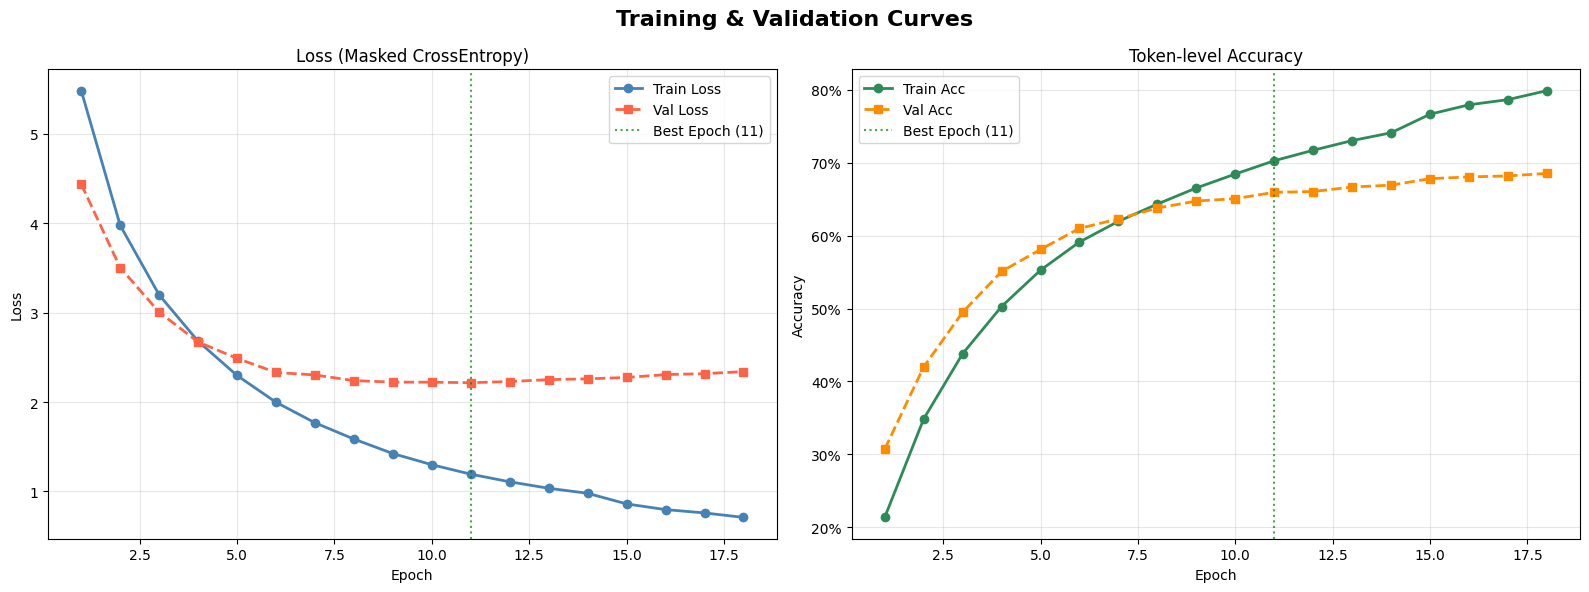

Saved: training_curves.png


In [ ]:
def plot_training_curves(history):                     ## Plot training & validation loss and accuracy curves from the history object.
    epochs_ran = len(history.history['loss'])
    ep = range(1, epochs_ran + 1)

    # Safely find accuracy keys regardless of exact name
    acc_key  = [k for k in history.history if 'accuracy' in k and 'val' not in k][0]
    vacc_key = [k for k in history.history if 'val' in k and 'accuracy' in k][0]

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    fig.suptitle("Training & Validation Curves", fontsize=16, fontweight='bold')

    # Loss
    axes[0].plot(ep, history.history['loss'],     'o-', color='steelblue', label='Train Loss', linewidth=2)
    axes[0].plot(ep, history.history['val_loss'], 's--', color='tomato',   label='Val Loss',   linewidth=2)
    axes[0].axvline(x=11, color='green', linestyle=':', alpha=0.7, label='Best Epoch (11)')
    axes[0].set_title("Loss (Masked CrossEntropy)")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # Accuracy
    axes[1].plot(ep, history.history[acc_key],  'o-', color='seagreen',   label='Train Acc', linewidth=2)
    axes[1].plot(ep, history.history[vacc_key], 's--', color='darkorange', label='Val Acc',   linewidth=2)
    axes[1].axvline(x=11, color='green', linestyle=':', alpha=0.7, label='Best Epoch (11)')
    axes[1].set_title("Token-level Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(alpha=0.3)
    axes[1].yaxis.set_major_formatter(ticker.PercentFormatter(xmax=1))

    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: training_curves.png")

plot_training_curves(history)

STEP 11: Model Evaluation on Test Dataset

In [ ]:
acc_key  = [k for k in history.history if 'accuracy' in k and 'val' not in k][0]
vacc_key = [k for k in history.history if 'val' in k and 'accuracy' in k][0]

print("Evaluating on test set...")
test_results = model.evaluate(
    [X_test, y_in_test],
    y_tgt_test,
    batch_size=CONFIG["batch_size"],
    verbose=1
)
test_loss, test_acc = test_results[0], test_results[1]
val_loss   = min(history.history['val_loss'])
val_acc    = max(history.history[vacc_key])
train_loss = min(history.history['loss'])
train_acc  = max(history.history[acc_key])

print(f"\n{'='*45}")
print(f"  Train  — Loss: {train_loss:.4f}  |  Acc: {train_acc*100:.2f}%")
print(f"  Val    — Loss: {val_loss:.4f}  |  Acc: {val_acc*100:.2f}%")
print(f"  Test   — Loss: {test_loss:.4f}  |  Acc: {test_acc*100:.2f}%")
print(f"{'='*45}")

Evaluating on test set...
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 254ms/step - loss: 2.2256 - masked_accuracy: 0.6582

  Train  — Loss: 0.7105  |  Acc: 79.86%
  Val    — Loss: 2.2163  |  Acc: 68.52%
  Test   — Loss: 2.2001  |  Acc: 66.06%


Step 12: Model Performance Comparison

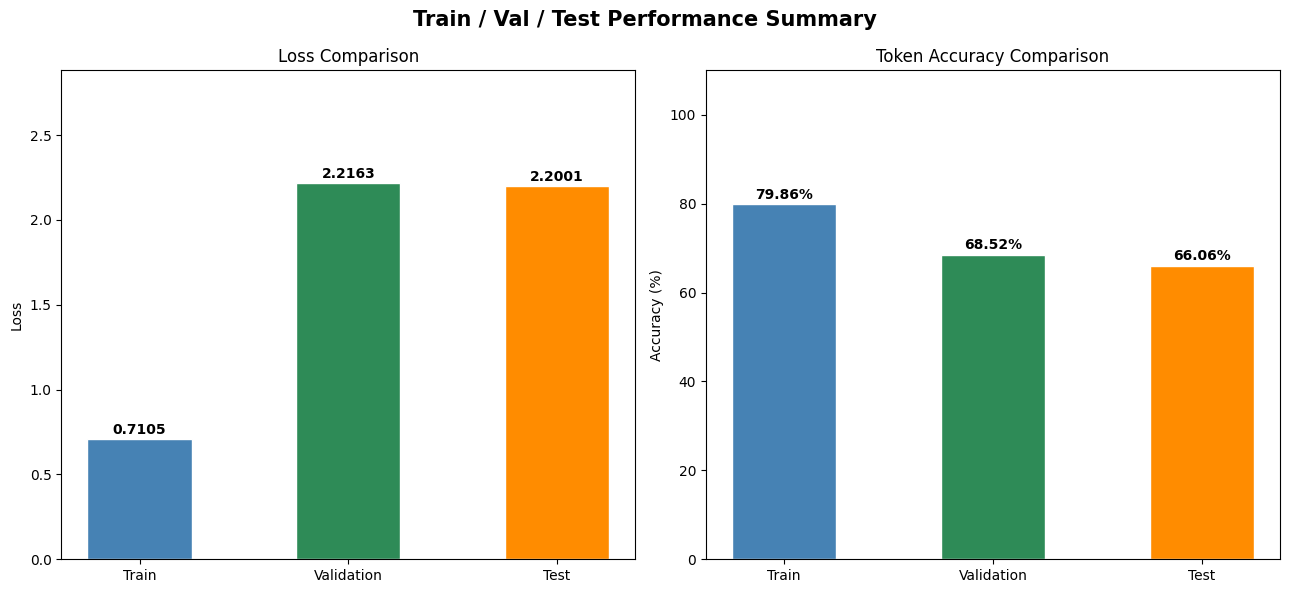

Saved: performance_summary.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 6))
fig.suptitle("Train / Val / Test Performance Summary", fontsize=15, fontweight='bold')

splits  = ['Train', 'Validation', 'Test']
losses  = [train_loss, val_loss, test_loss]
accs    = [train_acc,  val_acc,  test_acc]
colors  = ['steelblue', 'seagreen', 'darkorange']

bars1 = axes[0].bar(splits, losses, color=colors, edgecolor='white', width=0.5)
axes[0].set_title("Loss Comparison")
axes[0].set_ylabel("Loss")
axes[0].set_ylim(0, max(losses) * 1.3)
for bar, val in zip(bars1, losses):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontweight='bold')

bars2 = axes[1].bar(splits, [a*100 for a in accs], color=colors, edgecolor='white', width=0.5)
axes[1].set_title("Token Accuracy Comparison")
axes[1].set_ylabel("Accuracy (%)")
axes[1].set_ylim(0, 110)
for bar, val in zip(bars2, accs):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{val*100:.2f}%', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig("performance_summary.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: performance_summary.png")

STEP 13: Translation Inference using Beam Search with Attention Visualization

START_IDX: 3
END_IDX:   2

  SAMPLE TRANSLATIONS  (Beam Search, width=5)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'bahdanau_attention' (of type BahdanauAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


  EN: Hello, how are you?
  FR: écoutez comment vous êtes

  EN: I love Paris in the spring.
  FR: j'aime voyager sur le printemps

  EN: Can you speak more slowly please?
  FR: peux tu parler plus lentement s'il vous plaît

  EN: She is reading a book.
  FR: elle lit un livre

  EN: Hello my name is Aditya.
  FR: bonjour mon nom est crevé



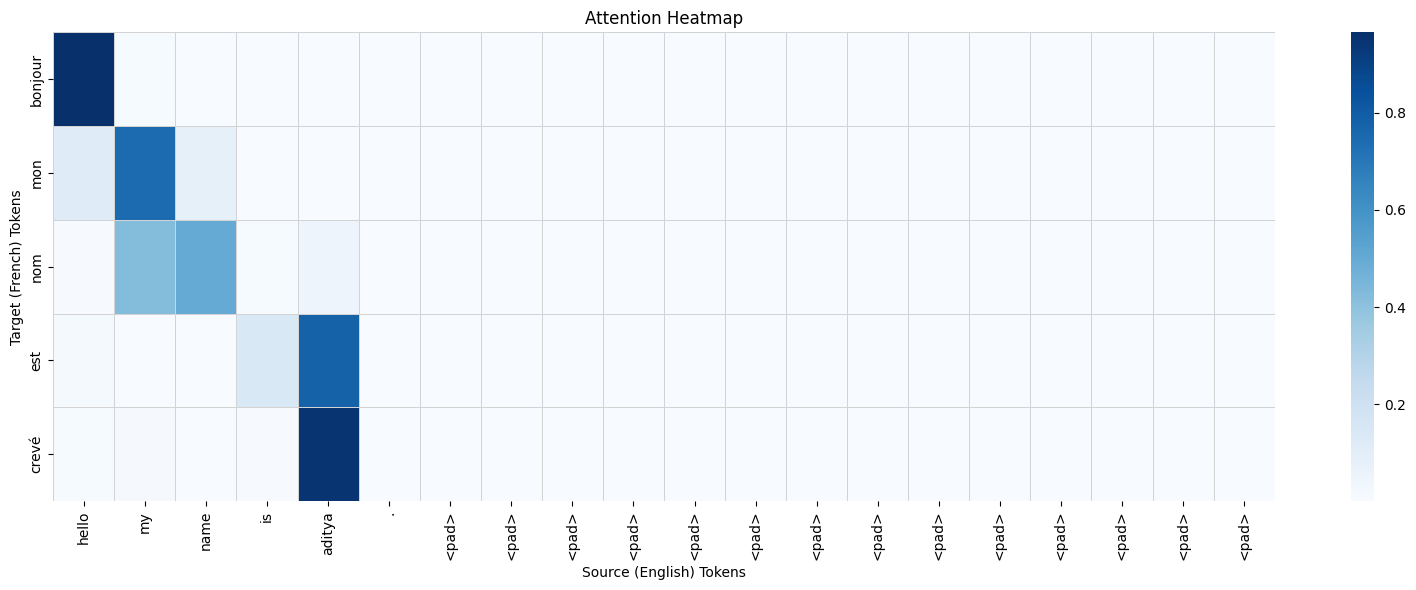

Saved: attention_heatmap.png


In [ ]:
fra_index_word = {v: k for k, v in fra_tokenizer.word_index.items()}

# Find the actual token keys (angle brackets may have been stripped by tokenizer)
START_IDX = fra_tokenizer.word_index.get("<start>") or fra_tokenizer.word_index.get("start")
END_IDX   = fra_tokenizer.word_index.get("<end>")   or fra_tokenizer.word_index.get("end")

print(f"START_IDX: {START_IDX}")
print(f"END_IDX:   {END_IDX}")

def plot_attention(translation, attention_weights, source_tokens):
    """Plots the attention weights for a given translation."""
    # Prepare data for plotting
    # attention_weights is a list of arrays, each (1, 1, enc_seq_len)
    # We want a 2D array (dec_seq_len, enc_seq_len)
    attention_matrix = np.array([attn.flatten() for attn in attention_weights])

    # Add <start> and <end> tokens to translated sentence for y-axis labels
    translated_tokens = translation.split()
    # Ensure the matrix and translated tokens align (handle potential length mismatches)
    # The attention matrix rows correspond to decoder output steps *before* token selection.
    # So its length should match the number of tokens in the translated sequence plus START_TOKEN
    # if the attention was computed for each output step.
    # For simplicity, let's assume `attention_weights` has one entry per output word.
    # If the attention_weights list contains more entries than actual translated tokens,
    # it might include attention for <start> or <end> tokens which we filter in `result`.
    # We need to ensure the number of rows in `attention_matrix` matches the length of `translated_tokens`.
    # The `translate_beam` function already filters out <start> and <end> from the `result` list.
    # The `attn_list` collected inside `translate_beam` corresponds to each generated token.
    # So, the number of rows in `attention_matrix` should correspond to `translated_tokens`.
    # Let's adjust to match length for robust plotting.

    # Pad source tokens if they are shorter than the attention matrix columns
    # The attention matrix columns correspond to the source_tokens + PAD_TOKENs up to MAX_ENG
    # We need to use the original preprocessed English sentence for x-axis labels
    # The source_tokens are already cleaned and split
    src_labels = source_tokens + ['<pad>'] * (MAX_ENG - len(source_tokens))
    tgt_labels = translated_tokens # Assuming attention_weights align with translated_tokens

    # Adjust attention_matrix to match the length of `translated_tokens` if necessary
    # It's possible `best_attn` from `translate_beam` could have more elements than `translated_tokens`
    # (e.g., if it includes attention for <end> token generation).
    if attention_matrix.shape[0] > len(translated_tokens):
        attention_matrix = attention_matrix[:len(translated_tokens), :]

    fig, ax = plt.subplots(figsize=(len(src_labels) * 0.8, len(tgt_labels) * 0.8 + 2))
    sns.heatmap(
        attention_matrix,
        xticklabels=src_labels,
        yticklabels=tgt_labels,
        cmap='Blues',
        linecolor='lightgrey',
        linewidths=0.5,
        cbar=True,
        ax=ax
    )
    ax.set_xlabel('Source (English) Tokens')
    ax.set_ylabel('Target (French) Tokens')
    ax.set_title('Attention Heatmap')
    plt.tight_layout()
    plt.savefig("attention_heatmap.png", dpi=150)
    plt.show()
    print("Saved: attention_heatmap.png")

##beam_width:number of candidate sequences explored simultaneously 
## max_len – maximum translation length
##alpha – length penalty factor

def translate_beam(sentence, beam_width=5, max_len=50, alpha=0.6): #
    """
    Beam search decoding — explores top-k paths simultaneously.
    alpha: length penalty (0=no penalty, 1=full penalty). 0.6 is standard.
    """
    sentence = preprocess_english(sentence)
    seq = eng_tokenizer.texts_to_sequences([sentence])
    seq = pad_sequences(seq, maxlen=MAX_ENG, padding='post')
    seq = tf.convert_to_tensor(seq)

    # Run encoder once
    enc_out, hidden = encoder_model(seq, training=False)

    # Each beam: (score, token_ids, hidden_state, attention_list)
    beams = [(0.0, [START_IDX], hidden, [])]
    completed = []

    for step in range(max_len):
        if not beams:
            break

        all_candidates = []

        for score, tokens, hidden_state, attn_list in beams:
            # If this beam already ended, carry it forward
            if tokens[-1] == END_IDX:
                completed.append((score, tokens, attn_list))
                continue

            dec_token = tf.expand_dims([tokens[-1]], 0)
            logits, new_hidden, attn_weights = decoder_model(
                dec_token, enc_out, hidden_state, training=False
            )

            # Convert logits to log probabilities
            log_probs = tf.nn.log_softmax(logits[0]).numpy()

            # Take top beam_width tokens
            top_k_ids = np.argsort(log_probs)[-beam_width:]

            for token_id in top_k_ids:
                new_score = score + log_probs[token_id]
                all_candidates.append((
                    new_score,
                    tokens + [token_id],
                    new_hidden,
                    attn_list + [attn_weights.numpy().squeeze()]
                ))

        if not all_candidates:
            break

        # Length penalty: prevents model from preferring short sequences
        def length_penalized_score(item):
            seq_len = len(item[1])
            penalty = ((5 + seq_len) / 6) ** alpha
            return item[0] / penalty

        # Keep top beam_width beams
        all_candidates.sort(key=length_penalized_score, reverse=True)
        beams = []
        for candidate in all_candidates[:beam_width]:
            if candidate[1][-1] == END_IDX:
                completed.append((candidate[0], candidate[1], candidate[3]))
            else:
                beams.append(candidate)

        # Early exit if we have enough completed beams
        if len(completed) >= beam_width:
            break

    # If nothing completed, take best active beam
    if not completed:
        completed = [(b[0], b[1], b[3]) for b in beams]

    # Pick best completed beam by length-penalized score
    def final_score(item):
        seq_len = len(item[1])
        penalty = ((5 + seq_len) / 6) ** alpha
        return item[0] / penalty

    best_score, best_tokens, best_attn = max(completed, key=final_score)

    # Decode tokens to words
    result = []
    for tok_id in best_tokens:
        if tok_id in (START_IDX, END_IDX):
            continue
        word = fra_index_word.get(tok_id, '')
        if word and word not in (CONFIG["START_TOKEN"], CONFIG["END_TOKEN"],
                                  CONFIG["OOV_TOKEN"], 'start', 'end'):
            result.append(word)

    translation = ' '.join(result)
    src_tokens  = sentence.split()

    return translation, best_attn, src_tokens


# Demo translations
test_sentences = [
    "Hello, how are you?",
    "I love Paris in the spring.",
    "Can you speak more slowly please?",
    "She is reading a book.",
    "Hello my name is Aditya.",
]

print("\n" + "="*55)
print("  SAMPLE TRANSLATIONS  (Beam Search, width=5)")
print("="*55)
for s in test_sentences:
    translation, attn, src_toks = translate_beam(s, beam_width=5)
    print(f"  EN: {s}")
    print(f"  FR: {translation}")
    print()

# Attention heatmap for last sentence
plot_attention(translation, attn, src_toks)


STEP 14: Translation Quality Evaluation using BLEU Score (Bilingual Evaluation Understudy)

Computing BLEU scores (this may take a minute)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:965: UserWarning: Layer 'bahdanau_attention' (of type BahdanauAttention) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(



  BLEU-1 : 23.58
  BLEU-2 : 17.38
  BLEU-4 : 10.14


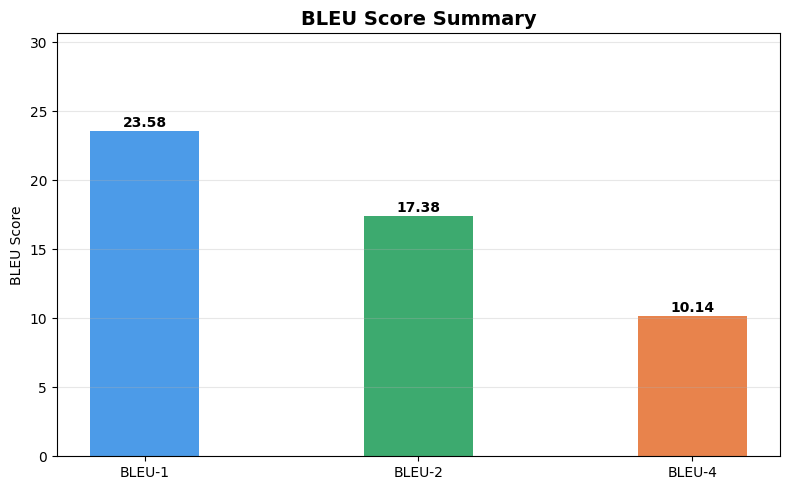

Saved: bleu_scores.png


In [ ]:
from nltk.translate.bleu_score import sentence_bleu, corpus_bleu, SmoothingFunction

def evaluate_bleu(num_samples=500):
    """Compute corpus BLEU on random test samples."""
    smoother = SmoothingFunction().method1
    indices  = random.sample(range(len(X_test)), min(num_samples, len(X_test)))

    references, hypotheses = [], []

    for idx in indices:
        src_seq = X_test[idx:idx+1]
        src_text = eng_tokenizer.sequences_to_texts(src_seq)[0]

        translation, _, _ = translate_beam(src_text, beam_width=5)   # was translate()

        # Reference: decode target without special tokens
        ref_seq   = y_tgt_test[idx]
        ref_tokens = []
        for tok_id in ref_seq:
            if tok_id == 0 or tok_id == END_IDX:
                break
            w = fra_index_word.get(tok_id, '')
            if w and w not in (CONFIG["START_TOKEN"], CONFIG["END_TOKEN"]):
                ref_tokens.append(w)

        references.append([ref_tokens])
        hypotheses.append(translation.split())

    bleu1 = corpus_bleu(references, hypotheses, weights=(1,0,0,0))          ##unigram overlap (word-level similarity)
    bleu2 = corpus_bleu(references, hypotheses, weights=(0.5,0.5,0,0))      ##bigram overlap (phrase-level similarity)
    bleu4 = corpus_bleu(references, hypotheses, weights=(0.25,)*4)          ##up to 4-gram overlap (fluency and word order)
 
    return bleu1, bleu2, bleu4

print("Computing BLEU scores (this may take a minute)...")
bleu1, bleu2, bleu4 = evaluate_bleu(500)

print(f"\n{'='*40}")
print(f"  BLEU-1 : {bleu1*100:.2f}")
print(f"  BLEU-2 : {bleu2*100:.2f}")
print(f"  BLEU-4 : {bleu4*100:.2f}")
print(f"{'='*40}")

# BLEU bar chart
fig, ax = plt.subplots(figsize=(8, 5))
bleus = [bleu1*100, bleu2*100, bleu4*100]
bars  = ax.bar(['BLEU-1','BLEU-2','BLEU-4'], bleus, color=['#4C9BE8','#3DAA6F','#E8834C'], width=0.4)
for bar, val in zip(bars, bleus):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f'{val:.2f}', ha='center', fontweight='bold')
ax.set_title("BLEU Score Summary", fontsize=14, fontweight='bold')
ax.set_ylabel("BLEU Score")
ax.set_ylim(0, max(bleus)*1.3)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("bleu_scores.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: bleu_scores.png")


STEP 15: Saving Model, Tokenizers, and Experiment Artifacts

In [ ]:
import pickle, os

# Save tokenizers
with open("eng_tokenizer.pkl", "wb") as f:
    pickle.dump(eng_tokenizer, f)
with open("fra_tokenizer.pkl", "wb") as f:
    pickle.dump(fra_tokenizer, f)

# Save CONFIG
with open("config.pkl", "wb") as f:
    pickle.dump(CONFIG, f)

# Save full model — native Keras 3 format (contains encoder + decoder inside)
model.save("nmt_model_full.keras")
print("Model saved.")

# Download all files
try:
    from google.colab import files
    for fname in [
        "eng_tokenizer.pkl", "fra_tokenizer.pkl", "config.pkl",
        "nmt_model_full.keras",
        "training_curves.png", "performance_summary.png",
        "dataset_statistics.png", "bleu_scores.png", "attention_heatmap.png"
    ]:
        if os.path.exists(fname):
            files.download(fname)
            print(f"  ✓ Downloaded: {fname}")
        else:
            print(f"  ✗ Skipped (not found): {fname}")
except ImportError:
    print("Not in Colab — files saved locally.")

print("\nAll done! 🎉")

Model saved.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✓ Downloaded: eng_tokenizer.pkl


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ✓ Downloaded: bleu_scores.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✓ Downloaded: attention_heatmap.png

All done! 🎉
